# Bước 1: Biết cách chạy lệnh DB

Tại `C:\Program Files\MySQL\MySQL Server 8.0\bin\` --> `mysqldump.exe`
- Đây là một file script thực thi, file nhị phân
- Nó thực hiện dumb Database
- Giống như vào Navicat và thao tác:
	1. Chuột phải vào Db
	2. Chọn Dumb SQL File -> Structure and Data
> Thì file `mysqldump.exe` sử dụng để Dumb file thành My SQL file nhưng thông qua dòng lệnh

# Bước 2: Cấu hình Terminal
Làm sao để mở Terminal và chạy được lệnh `mysqldump`

- Control Panel -> View advanced system settings -> Environment Variable -> System Variable -> PATH: `C:\Program Files\MySQL\MySQL Server 8.0\bin`

- Terminal: Nhập lệnh `mysqldump` (Chạy file `mysqldump.exe`)

- Backup DB với lệnh: `mysqldump -u [username] -p [database_name] > [backup.sql]`
VD: `mysqldump -uviet -pViet251001 -P3306 chat_dev2 > chat_dev2_020326.sql`
---
u: username
p: password
P: Port
chat_dev2: database_name
chat_dev2_020326.sql: output

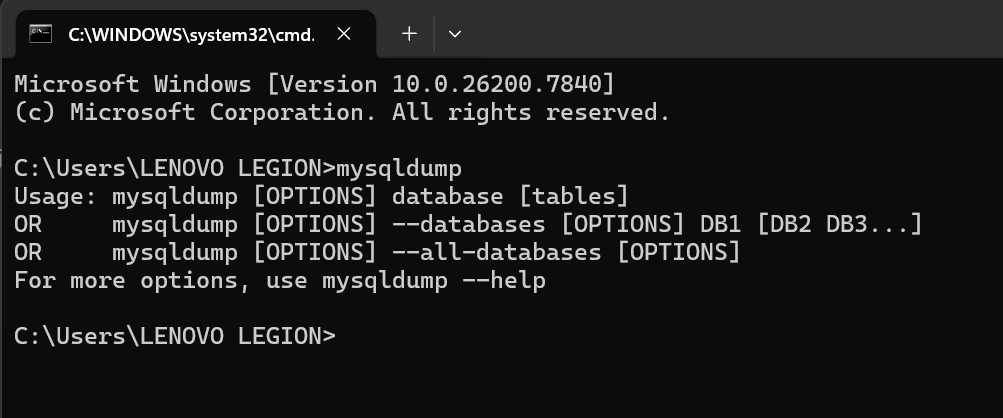

In [ ]:
Tóm lại:
Làm sao để chạy lệnh này `mysqldump -uviet -pViet251001 -P3306 chat_dev2 > chat_dev2_020326.sql` một cách tự động

> `node execute shell command`

In [ ]:

const { exec } = require('node:child_process'); 

/**
 * Mục tiêu: Thực thi lệnh liệt kê thư mục để giám sát tài nguyên
 * Tại sao: Cần kiểm tra dung lượng các file log định kỳ theo yêu cầu hệ thống
 */
exec('ls -lh', (error, stdout, stderr) => {
    // 1. Kiểm tra lỗi khởi tạo (System Error)
    // Tại sao: Sử dụng Early Return để code phẳng, tránh lồng ghép if-else quá sâu
    if (error) {
        // Log lỗi chi tiết để DevOps dễ dàng debug
        console.error(`Lỗi khởi tạo tiến trình: ${error.message}`);
        return;
    }

    // 2. Kiểm tra lỗi thực thi từ câu lệnh (Shell Error)
    // Tại sao: stderr có thể chứa cảnh báo ngay cả khi lệnh vẫn chạy được
    if (stderr) {
        console.error(`Lỗi từ câu lệnh shell: ${stderr}`);
        // Tùy nghiệp vụ, có thể return ở đây nếu lỗi này là nghiêm trọng
    }

    // 3. Kết quả thành công (Standard Output)
    // Hiển thị nội dung lấy được từ hệ điều hành
    console.log('--- KẾT QUẢ THỰC THI ---');
    console.log(stdout);
});

In [ ]:
- `const { exec } = require('child_process');`:
  - Chúng ta đang nạp module `child_process` có sẵn của Node.js.
  - **Lưu ý chuyên nghiệp**: Theo quy tắc hệ thống, em nên dùng prefix node: cho các module nội bộ, ví dụ: `require('node:child_process')`.

- `exec('ls -lh', (error, stdout, stderr) => { ... });`:
  - Hàm `exec` sẽ tạo ra một "tiến trình con" (child process) để chạy lệnh `ls -lh`.
  - Nó hoạt động theo cơ chế **Bất đồng bộ (Asynchronous)**: Node.js sẽ giao việc cho hệ điều hành rồi đi làm việc khác, khi nào hệ điều hành làm xong thì mới gọi hàm callback bên trong.

- **Ba tham số trả về (Callback params)**:
  - `error`: Nếu không thể tạo tiến trình hoặc lệnh bị lỗi nghiêm trọng (ví dụ: sai cú pháp lệnh), biến này sẽ chứa thông tin lỗi.
  - `stdout` (*Standard Output*): Chứa kết quả thành công mà lệnh đó trả về (danh sách file).
  - `stderr` (*Standard Error*): Chứa các thông báo lỗi hoặc cảnh báo từ chính câu lệnh đó khi nó đang thực thi.

- Lệnh `ls -lh`:
	- Một lệnh Linux/macOS để liệt kê chi tiết các file trong thư mục
	- Lấy kết quả trả về để hiển thị trong Console.


# 3. Ẩn dụ nhanh (Quick Analogy)
- Đoạn code này giống như việc em thuê một thợ sửa ống nước (Child Process):
	- Lệnh `ls -lh`: Công việc cụ thể em giao (Kiểm tra đường ống).
	- `error`: Người thợ thậm chí không đến được nhà em (Lỗi khởi tạo tiến trình).
	- `stderr`: Người thợ đến được nhưng báo là "Không mang đủ đồ nghề" (Lỗi từ câu lệnh).
	- `stdout`: Người thợ làm xong và báo cáo "Ống nước đã thông" (Kết quả thành công).